In [15]:
import numpy as np
from math import sqrt
import matplotlib.pyplot as plt

In [16]:
def gerarmalha(num_pontos, limite_lateral, limite_superior):
    c = limite_lateral / (limite_superior - 0.003)
    
    # 1. Calcula o NÚMERO DE PONTOS (inteiros)
    N_y = int(round(sqrt(num_pontos / c)))
    N_x = int(round(num_pontos / N_y))
    
    # 2. Cria os vetores de coordenadas 1D
    # np.linspace(inicio, fim, num_pontos) JÁ INCLUI OS FINAIS!
    x_vetor = np.linspace(start=0, stop=limite_lateral, num=N_x)
    y_vetor = np.linspace(start=0.003, stop=limite_superior, num=N_y)
    
    # 3. Calcula dx e dy (se precisar deles)
    dx = limite_lateral / (N_x - 1) if N_x > 1 else 0
    dy = (limite_superior - 0.003) / (N_y - 1) if N_y > 1 else 0 # com parenteses
    
    # 4. Cria a malha 2D
    # X terá a coordenada x de CADA ponto
    # Y terá a coordenada y de CADA ponto
    X, Y = np.meshgrid(x_vetor, y_vetor)
    
    return X, Y, dx, dy, N_x, N_y

In [17]:
def fluxotermico(valor_x):
    x = valor_x * 1000
    if x == 0:
        return 0
    elif x == 150:
        return 0
    elif int(x/10) % 2:
        return  150000/7
    else:
        return 0

GERANDO MATRIZES CORRESPONDENTES A CADA CASO:

COMEÇANDO COM PONTOS INTERNOS

In [18]:
#[i][j] = (y, x)
def internpoints(A_p, A_n, A_s, A_w, A_e, B, R_p, Ny, Nx, dx, dy, k, h):
    for i in range (1, Ny-1):
        for j in range (1,Nx-1):
            r_n = (R_p[i+1][j] + R_p[i] [j])/2
            r_s = (R_p[i-1][j] + R_p[i] [j])/2
            r_p = R_p[i][j]
            
            A_p[i][j] = -(k *r_n * dx / dy) - (k * r_s * dx / dy) - (2 * k *r_p * dy / dx)
            A_n[i][j] = k * r_n * dx / dy
            A_s[i][j] = k * r_s * dx / dy
            A_w[i][j] = k * r_p * dy / dx
            A_e[i][j] = k * r_p * dy /dx
            B[i][j] = 0


PONTOS DE QUINA

In [19]:
def cornerpoints(A_p, A_n, A_s, A_w, A_e, B, R_p, Ny, Nx, dx, dy, k, h, T_inf, X):
    #Ponto 1 Cordenadas ([Ny-1][0])
    r_s = (R_p[Ny-2][0] + R_p[Ny-1][0]) / 2
    r_p = R_p[Ny-1][0]

    A_p[Ny-1][0] = -(k * r_s * dx / (dy*2)) -( k * r_p * dy / (dx*2)) - (h * r_p * dx / 2)
    A_n[Ny-1][0] = 0
    A_s[Ny-1][0] = k * r_s * dx / (dy*2)
    A_w[Ny-1][0] = 0
    A_e[Ny-1][0] = k * r_p * dy / (dx*2)
    B[Ny-1][0] = -h * r_p * dx * T_inf / 2
     

    #Ponto 3 ([Ny-1][Nx-1])
    r_s = (R_p[Ny-2][Nx-1] + R_p[Ny-1][Nx-1]) / 2
    r_p = R_p[Ny-1][Nx-1]

    A_p[Ny-1][Nx-1] = -(k * r_s * dx / (dy*2)) - (k * r_p * dy / (dx*2)) - (h * r_p * dx / 2) 
    A_n[Ny-1][Nx-1]= 0
    A_s[Ny-1][Nx-1] = k * r_s * dx / (dy*2)
    A_w[Ny-1][Nx-1]= k * r_p * dy / (dx*2)
    A_e[Ny-1][Nx-1] = 0
    B[Ny-1][Nx-1] = -h * r_p * dx * T_inf / 2

    #Ponto 7 Coordenadas ([0][0])

    r_n = (R_p[1][0] + R_p[0][0]) / 2
    r_p = R_p[0][0]

    A_p[0][0] = -(k * r_n * dx / (dy*2)) -(k * r_p * dy / (dx*2))
    A_n[0][0]= k * r_n * dx / (dy*2)
    A_s[0][0] = 0
    A_w[0][0]= 0
    A_e[0][0] = k * r_p * dy / (dx*2)
    B[0][0] = -r_p * dx * fluxotermico(X[0][0]) / 2

    #Ponto 9 Coordenadas ([0][Nx-1])

    r_n = (R_p[1][Nx-1] + R_p[0][Nx-1]) / 2
    r_p = R_p[0][Nx-1]

    A_p[0][Nx-1] = -(k * r_n * dx / (dy*2)) - (k * r_p * dy / (dx*2))
    A_n[0][Nx-1]= k * r_n * dx / (dy*2)
    A_s[0][Nx-1] = 0
    A_w[0][Nx-1]= k * r_p * dy / (dx*2)
    A_e[0][Nx-1] = 0
    B[0][Nx-1] = -r_p * dx * fluxotermico(X[0][Nx-1]) / 2

In [20]:
def edgepoints(A_p, A_n, A_s, A_w, A_e, B, R_p, Ny, Nx, dx, dy, k, h, T_inf, X):
    #Ponto 2 Coordenadas ([Ny-1][range(1,Nx-1)])
    for j in range (1, Nx-1): 
        r_s = (R_p[Ny-2][j] + R_p[Ny-1][j])/2   
        r_p = R_p[Ny-1][j]

        A_p[Ny-1][j] = -k * r_s * dx / dy - k * r_p * dy / dx - h * r_p * dx 
        A_n[Ny-1][j] = 0
        A_s[Ny-1][j] = k * r_s * dx / dy
        A_w[Ny-1][j] = k * r_p * dy / (dx*2)
        A_e[Ny-1][j] = k * r_p * dy / (dx*2)
        B[Ny-1][j] = -h * r_p * dx * T_inf

    # Ponto 4 Coordenadas ([range(1,Ny-1)][0]])
    for i in range (1,Ny-1): 
        r_s = (R_p[i-1][0] + R_p[i][0])/2  
        r_n = (R_p[i+1][0] + R_p[i][0])/2  
        r_p = R_p[i][0]

        A_p[i][0] = -(k * r_n * dx / (dy*2)) - (k * r_s * dx / (dy*2)) - (k * r_p * dy / dx)
        A_n[i][0] = k * r_n * dx / (dy*2)
        A_s[i][0] = k * r_s * dx / (dy*2)
        A_w[i][0] = 0
        A_e[i][0] = k * r_p * dy / dx
        B[i][0] = 0
    
    # Ponto 6 Coordenadas ([range(1,Ny-1)][Nx-1]])
    for i in range (1,Ny-1): 
        r_s = (R_p[i-1][Nx-1] + R_p[i][Nx-1])/2  
        r_n = (R_p[i+1][Nx-1] + R_p[i][Nx-1])/2  
        r_p = R_p[i][Nx-1]

        A_p[i][Nx-1] = -(k * r_n * dx / (dy*2)) - (k * r_s * dx / (dy*2)) - (k * r_p * dy / dx)
        A_n[i][Nx-1] = k * r_n * dx / (dy*2)
        A_s[i][Nx-1] = k * r_s * dx / (dy*2)
        A_w[i][Nx-1] = k * r_p * dy / dx
        A_e[i][Nx-1] = 0
        B[i][Nx-1] = 0

    # Ponto 8 Coordenadas ([0][range(1,Nx-1)])
    for j in range (1, Nx-1): 
        r_n = (R_p[1][j] + R_p[0][j])/2   
        r_p = R_p[0][j]

        A_p[0][j] = -(k * r_n * dx / dy) - (k * r_p * dy / dx )
        A_n[0][j] = k * r_n * dx / dy
        A_s[0][j] = 0
        A_w[0][j] = k * r_p * dy / (dx*2)
        A_e[0][j] = k * r_p * dy / (dx*2)
        B[0][j] = -r_p * dx  * fluxotermico(X[0][j])

Criando funcoes para transformar matriz em vetor e vetor em matriz


In [21]:
def matrixtovec(i, j, Nx):
    return i * Nx + j

def vectomatrix(m, Nx):
    i = int(m/Nx)
    j = m % Nx
    return i, j

Agora vamos construir o sistema linear na forma:

    A * x = b

In [22]:
def make_A_b(A_p, A_n, A_s, A_w, A_e, B, Ny, Nx):
    
    A = np.zeros((Nx*Ny, Nx*Ny))
    b = np.zeros(Nx*Ny)
    for i in range (0, Ny):
        for j in range (0, Nx):
            index_p = matrixtovec(i, j, Nx)
            index_ps = matrixtovec(i-1, j, Nx) if i>0 else "N existe"
            index_pn = matrixtovec(i+1, j, Nx) if i<Ny-1 else "N existe"
            index_pe = matrixtovec(i, j+1, Nx) if j<Nx-1 else "N existe"
            index_pw = matrixtovec(i, j-1, Nx) if j>0 else "N existe"
            
            if index_p != "N existe":
                A[index_p][index_p] = A_p[i,j]
            if index_ps != "N existe":
                A[index_p][index_ps] = A_s[i,j]
            if index_pn != "N existe":
                A[index_p][index_pn] = A_n[i,j]
            if index_pe != "N existe":
                A[index_p][index_pe] = A_e[i,j]
            if index_pw != "N existe":
                A[index_p][index_pw] = A_w[i,j]

            b[index_p] = B[i][j]
    return A, b

MAIN

In [23]:
def main(m):
    k = 125
    h = 200
    T_inf = 45 + 273.15
    X, Y, dx, dy, Nx, Ny = gerarmalha(m, limite_lateral=0.15, limite_superior=0.009)

    print(f"Nx={Nx}, Ny={Ny}, Total de Pontos={Nx*Ny}")
    print(f"dx={dx:.4f}, dy={dy:.4f}\n")

    print("Matriz X (coordenadas x):")
    print(X)
    print("\nMatriz Y (coordenadas y):")
    print(Y)

    A_p = np.zeros(shape=(Ny , Nx))
    A_n = np.zeros(shape=(Ny , Nx))
    A_s = np.zeros(shape=(Ny , Nx))
    A_w = np.zeros(shape=(Ny , Nx))
    A_e = np.zeros(shape=(Ny , Nx))
    B = np.zeros(shape=(Ny , Nx))
    print(f"B tem {B.shape}")
    R_p = Y

    internpoints(A_p, A_n, A_s, A_w, A_e, B, R_p, Ny, Nx, dx, dy, k, h)
    cornerpoints(A_p, A_n, A_s, A_w, A_e, B, R_p, Ny, Nx, dx, dy, k, h, T_inf, X)
    edgepoints(A_p, A_n, A_s, A_w, A_e, B, R_p, Ny, Nx, dx, dy, k, h, T_inf, X)
    A, b = make_A_b(A_p, A_n, A_s, A_w, A_e, B, Ny, Nx)

    Tvetor = np.linalg.solve(A,b)

    T = np.zeros((Ny,Nx))

    for m in range (0, Nx*Ny):
        i, j = vectomatrix(m, Nx)
        T[i,j] = Tvetor[m]

    plt.figure(figsize=(12, 4))
        # Figura mais larga para corresponder à geometria

    # contourf é ótimo para dados suaves como temperatura
    # levels=100 cria mais "faixas" de cor
    # cmap='inferno' é um bom mapa de cores para calor (preto-vermelho-amarelo)
    plt.contourf(X, Y, T, levels=100, cmap='jet')
    plt.contourf(X, -Y, T, levels=100, cmap='jet')

    # Adiciona a barra de cores
    plt.colorbar(label='Temperatura (K)')

    plt.xlabel('Comprimento (z) [m]')
    plt.ylabel('Raio (r) [m]')
    plt.title('Perfil de Temperatura 2D')

    # Você pode forçar o aspecto para ser "real", mas o gráfico ficará muito fino
    # plt.axis('equal') 
    plt.axis('equal')
    plt.tight_layout() # Ajusta a figura
    plt.show()

    # %%
    # Plot opcional com pcolormesh (mostra as "células" da malha)
    plt.figure(figsize=(12, 4))
    plt.pcolormesh(X, Y, T, shading='gouraud', cmap='jet')
    plt.colorbar(label='Temperatura (K)')
    plt.xlabel('Comprimento (z) [m]')
    plt.ylabel('Raio (r) [m]')
    plt.title('Perfil de Temperatura 2D (pcolormesh)')
    plt.axis('equal')
    plt.tight_layout()
    plt.show()

    return T

            

    


    

In [24]:
def main(m):
    #k = 125
    k = 14.6
    h = 200
    T_inf = 45 + 273.15
    X, Y, dx, dy, Nx, Ny = gerarmalha(m, limite_lateral=0.15, limite_superior=0.009)

    print(f"Nx={Nx}, Ny={Ny}, Total de Pontos={Nx*Ny}")
    print(f"dx={dx:.4f}, dy={dy:.4f}\n")

    print("Matriz X (coordenadas x):")
    print(X)
    print("\nMatriz Y (coordenadas y):")
    print(Y)

    A_p = np.zeros(shape=(Ny , Nx))
    A_n = np.zeros(shape=(Ny , Nx))
    A_s = np.zeros(shape=(Ny , Nx))
    A_w = np.zeros(shape=(Ny , Nx))
    A_e = np.zeros(shape=(Ny , Nx))
    B = np.zeros(shape=(Ny , Nx))
    print(f"B tem {B.shape}")
    R_p = Y

    internpoints(A_p, A_n, A_s, A_w, A_e, B, R_p, Ny, Nx, dx, dy, k, h)
    cornerpoints(A_p, A_n, A_s, A_w, A_e, B, R_p, Ny, Nx, dx, dy, k, h, T_inf, X)
    edgepoints(A_p, A_n, A_s, A_w, A_e, B, R_p, Ny, Nx, dx, dy, k, h, T_inf, X)
    A, b = make_A_b(A_p, A_n, A_s, A_w, A_e, B, Ny, Nx)

    Tvetor = np.linalg.solve(A,b)

    T = np.zeros((Ny,Nx))

    for m in range (0, Nx*Ny):
        i, j = vectomatrix(m, Nx)
        T[i,j] = Tvetor[m]

    return T

Nx=29, Ny=2, Total de Pontos=58
dx=0.0054, dy=0.0060

Matriz X (coordenadas x):
[[0.         0.00535714 0.01071429 0.01607143 0.02142857 0.02678571
  0.03214286 0.0375     0.04285714 0.04821429 0.05357143 0.05892857
  0.06428571 0.06964286 0.075      0.08035714 0.08571429 0.09107143
  0.09642857 0.10178571 0.10714286 0.1125     0.11785714 0.12321429
  0.12857143 0.13392857 0.13928571 0.14464286 0.15      ]
 [0.         0.00535714 0.01071429 0.01607143 0.02142857 0.02678571
  0.03214286 0.0375     0.04285714 0.04821429 0.05357143 0.05892857
  0.06428571 0.06964286 0.075      0.08035714 0.08571429 0.09107143
  0.09642857 0.10178571 0.10714286 0.1125     0.11785714 0.12321429
  0.12857143 0.13392857 0.13928571 0.14464286 0.15      ]]

Matriz Y (coordenadas y):
[[0.003 0.003 0.003 0.003 0.003 0.003 0.003 0.003 0.003 0.003 0.003 0.003
  0.003 0.003 0.003 0.003 0.003 0.003 0.003 0.003 0.003 0.003 0.003 0.003
  0.003 0.003 0.003 0.003 0.003]
 [0.009 0.009 0.009 0.009 0.009 0.009 0.009 0.009 0

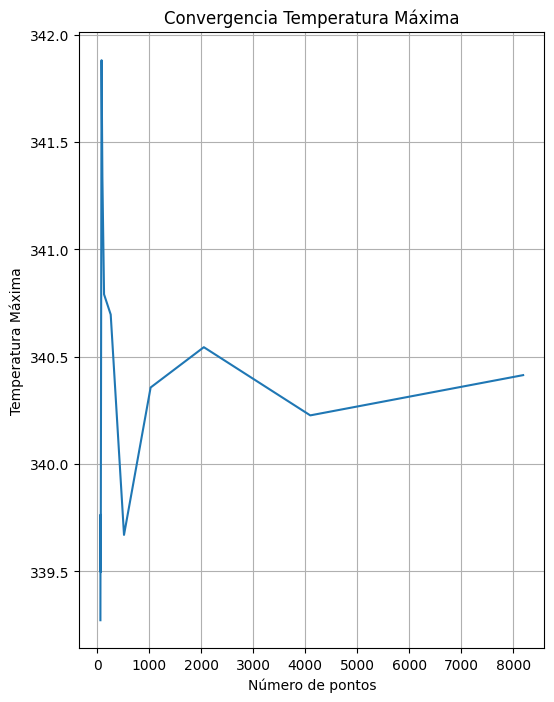

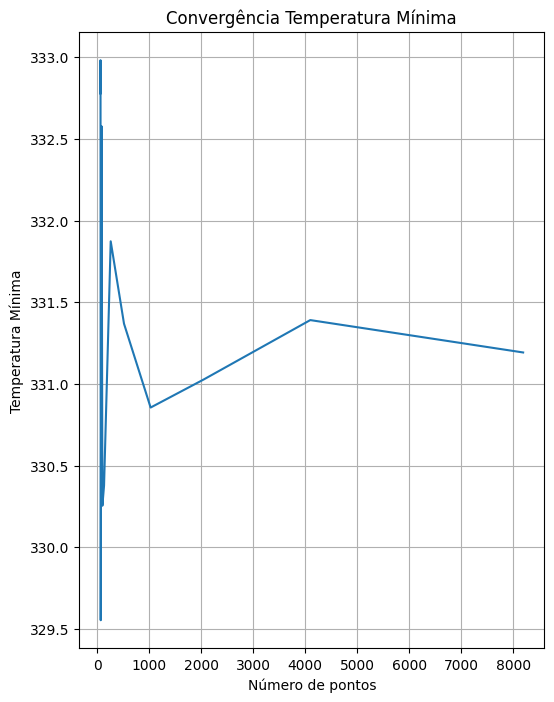

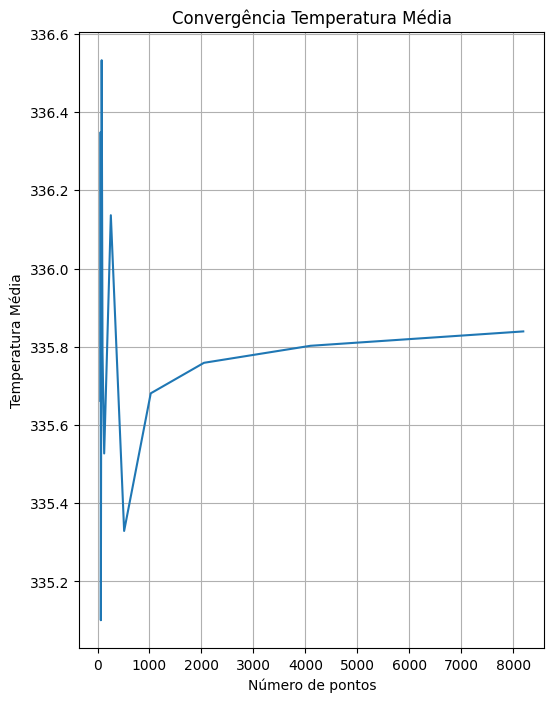

In [ ]:
listI = []
listTMAX = []
listTMIN = []
listTMED = []
j=2
for i in range (57, 66000): 
    if i%j==0:
        listI.append(i)
        T = main(i)
        listTMAX.append(T.max())
        listTMIN.append(T.min())
        listTMED.append(T.mean())
        j = j*2

fig1, ax1 = plt.subplots(num=1,figsize=(6,8))
fig2, ax2 = plt.subplots(num=2,figsize=(6,8))
fig3, ax3 = plt.subplots(num=3,figsize=(6,8))

ax1.set_title("Convergencia Temperatura Máxima")
ax1.set_xlabel("Número de pontos")
ax1.set_ylabel("Temperatura Máxima")
ax1.grid()

ax2.set_title("Convergência Temperatura Mínima")
ax2.set_xlabel("Número de pontos")
ax2.set_ylabel("Temperatura Mínima")
ax2.grid()


ax3.set_title("Convergência Temperatura Média")
ax3.set_xlabel("Número de pontos")
ax3.set_ylabel("Temperatura Média")
ax3.grid()

ax1.plot(listI, listTMAX)
ax2.plot(listI, listTMIN)
ax3.plot(listI, listTMED)

In [26]:
def main(m):
    k = 125
    #k = 14.6
    h = 200
    T_inf = 45 + 273.15
    X, Y, dx, dy, Nx, Ny = gerarmalha(m, limite_lateral=0.15, limite_superior=0.009)

    print(f"Nx={Nx}, Ny={Ny}, Total de Pontos={Nx*Ny}")
    print(f"dx={dx:.4f}, dy={dy:.4f}\n")

    print("Matriz X (coordenadas x):")
    print(X)
    print("\nMatriz Y (coordenadas y):")
    print(Y)

    A_p = np.zeros(shape=(Ny , Nx))
    A_n = np.zeros(shape=(Ny , Nx))
    A_s = np.zeros(shape=(Ny , Nx))
    A_w = np.zeros(shape=(Ny , Nx))
    A_e = np.zeros(shape=(Ny , Nx))
    B = np.zeros(shape=(Ny , Nx))
    print(f"B tem {B.shape}")
    R_p = Y

    internpoints(A_p, A_n, A_s, A_w, A_e, B, R_p, Ny, Nx, dx, dy, k, h)
    cornerpoints(A_p, A_n, A_s, A_w, A_e, B, R_p, Ny, Nx, dx, dy, k, h, T_inf, X)
    edgepoints(A_p, A_n, A_s, A_w, A_e, B, R_p, Ny, Nx, dx, dy, k, h, T_inf, X)
    A, b = make_A_b(A_p, A_n, A_s, A_w, A_e, B, Ny, Nx)

    Tvetor = np.linalg.solve(A,b)

    T = np.zeros((Ny,Nx))

    for m in range (0, Nx*Ny):
        i, j = vectomatrix(m, Nx)
        T[i,j] = Tvetor[m]

    return T

In [27]:
listI = []
listTMAX = []
listTMIN = []
listTMED = []
j=2
for i in range (57, 66000):
    if i%j==0:
        listI.append(i)
        T = main(i)
        listTMAX.append(T.max())
        listTMIN.append(T.min())
        listTMED.append(T.mean())
        j = j*2

fig1, ax1 = plt.subplots(num=1,figsize=(6,8))
fig2, ax2 = plt.subplots(num=2,figsize=(6,8))
fig3, ax3 = plt.subplots(num=3,figsize=(6,8))

ax1.set_title("Convergencia Temperatura Máxima")
ax1.set_xlabel("Número de pontos")
ax1.set_ylabel("Temperatura Máxima")
ax1.grid()

ax2.set_title("Convergência Temperatura Mínima")
ax2.set_xlabel("Número de pontos")
ax2.set_ylabel("Temperatura Mínima")
ax2.grid()


ax3.set_title("Convergência Temperatura Média")
ax3.set_xlabel("Número de pontos")
ax3.set_ylabel("Temperatura Média")
ax3.grid()

ax1.plot(listI, listTMAX)
ax2.plot(listI, listTMIN)
ax3.plot(listI, listTMED)

Nx=29, Ny=2, Total de Pontos=58
dx=0.0054, dy=0.0060

Matriz X (coordenadas x):
[[0.         0.00535714 0.01071429 0.01607143 0.02142857 0.02678571
  0.03214286 0.0375     0.04285714 0.04821429 0.05357143 0.05892857
  0.06428571 0.06964286 0.075      0.08035714 0.08571429 0.09107143
  0.09642857 0.10178571 0.10714286 0.1125     0.11785714 0.12321429
  0.12857143 0.13392857 0.13928571 0.14464286 0.15      ]
 [0.         0.00535714 0.01071429 0.01607143 0.02142857 0.02678571
  0.03214286 0.0375     0.04285714 0.04821429 0.05357143 0.05892857
  0.06428571 0.06964286 0.075      0.08035714 0.08571429 0.09107143
  0.09642857 0.10178571 0.10714286 0.1125     0.11785714 0.12321429
  0.12857143 0.13392857 0.13928571 0.14464286 0.15      ]]

Matriz Y (coordenadas y):
[[0.003 0.003 0.003 0.003 0.003 0.003 0.003 0.003 0.003 0.003 0.003 0.003
  0.003 0.003 0.003 0.003 0.003 0.003 0.003 0.003 0.003 0.003 0.003 0.003
  0.003 0.003 0.003 0.003 0.003]
 [0.009 0.009 0.009 0.009 0.009 0.009 0.009 0.009 0

KeyboardInterrupt: 